# RID data audit and geographic split

**Stage 1 scientific report.** This notebook asks whether RID 1.0 provides a defensible foundation for studying data-efficient binary roof segmentation. We verify the paired raster and label contract, inspect representative development examples, quantify class coverage and exact duplicates, and construct a geographic split that keeps the provider test region locked. No model is trained here.

The main result is a conservative development set of **940 training** and **289 validation** images, plus all **154 locked test** images. A further **497 images** are excluded because their footprints cross roles or because they are byte-identical duplicates. These counts are read from saved records below rather than typed into the analysis.

## 1. Data source and audit method

RID is the Roof Information Dataset by Krapf et al. ([dataset DOI](https://doi.org/10.14459/2022mp1655470); [paper](https://mediatum.ub.tum.de/doc/1735413/document.pdf)). It contains roof-centred Google Maps aerial images from Wartenberg, Germany. The provider warns that adjacent images overlap. The release README states CC BY-NC terms and a separate Google imagery-use notice; these constraints are summarized in `docs/data.md`.

Before this notebook runs, `scripts/prepare_data.py` compares every required raw file with the provider SHA-256 list and writes two shared records: one manifest for pairing and file identity, and one split file for exact role and subset membership. The notebook reads those records; it does not alter raw data.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from roofseg.plots import plot_examples, plot_split_map, representative_ids

ROOT = Path.cwd()
MANIFEST = json.loads((ROOT / "data/metadata/data_manifest.json").read_text())
SPLITS = json.loads((ROOT / "data/metadata/splits.json").read_text())
AUDIT = json.loads((ROOT / "reports/data_audit.json").read_text())
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

### Inventory and raster contract

The audit requires a one-to-one match between numeric image and mask IDs. It then opens every file and checks shape, data type, coordinate reference system (CRS), valid-pixel mask and observed label codes. A CRS describes how raster coordinates relate to positions on Earth.

In [2]:
inventory = pd.DataFrame({
    "property": ["Paired samples", "Image array", "Image CRS", "Image validity", "Mask array", "Observed mask codes"],
    "verified value": [
        MANIFEST["audit"]["pair_count"],
        "512 × 512 × 3, uint8 RGB",
        ", ".join(MANIFEST["audit"]["image_crs"]),
        "all pixels valid; no alpha band or nodata",
        "512 × 512, uint8, single channel",
        f"{min(MANIFEST['audit']['mask_values_observed'])}–{max(MANIFEST['audit']['mask_values_observed'])}",
    ],
})
display(inventory.style.hide(axis="index"))

property,verified value
Paired samples,1880
Image array,"512 × 512 × 3, uint8 RGB"
Image CRS,EPSG:4326
Image validity,all pixels valid; no alpha band or nodata
Mask array,"512 × 512, uint8, single channel"
Observed mask codes,0–17


**Verified finding.** All 1,880 GeoTIFFs have the same RGB contract, declare EPSG:4326 and have a paired reviewed segment mask. All codes 0–17 occur. There is no alpha channel, nodata declaration or unknown mask code, so every pixel has an input value and a provider-defined class. This is a file-format validity statement, not proof that every visible roof is annotated perfectly.

## 2. Binary roof target and label coverage

The release README lists background, sixteen azimuth directions and flat roof but does not make their numeric order sufficiently explicit. The official generation code resolves it: `definitions.py` assigns azimuth classes to 0–15 and flat roof to 16; `mask_generation.py` initializes background as `len(label_classes)`, which is 17. We therefore define the binary target as **roof = mask != 17**. This is a consequential correction to an initially attempted reversed interpretation, made before the references were committed.

In [3]:
label_table = pd.DataFrame({
    "codes": ["0–15", "16", "17"],
    "provider meaning": ["roof azimuth bins", "flat roof", "background"],
    "binary target": ["roof", "roof", "background"],
})
display(label_table.style.hide(axis="index"))
AUDIT["roof_fraction_summary"]

codes,provider meaning,binary target
0–15,roof azimuth bins,roof
16,flat roof,roof
17,background,background


{'minimum': 0.0,
 'median': 0.23313140869140625,
 'mean': 0.24063647452821124,
 'maximum': 0.7359619140625,
 'empty_masks': 1,
 'full_masks': 0}

Across the release, roof pixels occupy 24.1% of the raster area. Individual masks range from 0.0% to 73.6% roof, with a median of 23.3%. ID 39 is the only empty mask and is retained in validation because a valid negative example is useful for detecting false positives. Later metrics must explicitly define empty-target behavior; mean per-image IoU should not silently turn an empty/empty result into an arbitrary number.

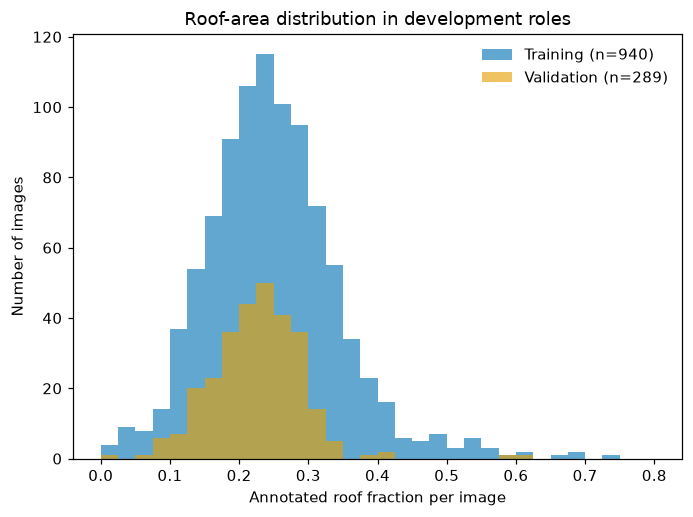

In [4]:
records = pd.DataFrame(MANIFEST["samples"])
role_by_id = {sample_id: role for role, ids in SPLITS["roles"].items() for sample_id in ids}
records["role"] = records["id"].map(role_by_id)
records["roof_fraction"] = records["roof_pixels"] / (512 * 512)

for role, colour in [("training", "#0072B2"), ("validation", "#E69F00")]:
    values = records.loc[records.role == role, "roof_fraction"]
    plt.hist(values, bins=np.linspace(0, 0.8, 33), alpha=0.62, label=f"{role.title()} (n={len(values)})", color=colour)
plt.xlabel("Annotated roof fraction per image")
plt.ylabel("Number of images")
plt.title("Roof-area distribution in development roles")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(ROOT / "reports/figures/roof_fraction_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

**Interpretation.** Training and validation both span small and large roofs, although image count is only a rough proxy for annotation effort because labelled area and geometric complexity vary. The locked test labels are deliberately absent from this development distribution.

## 3. Representative development examples

The following gallery selects low, median and high roof-area examples independently from the final training and validation roles. Selection uses only reference-mask area, not model behavior. Magenta denotes the binary roof target. Test imagery remains uninspected during development.

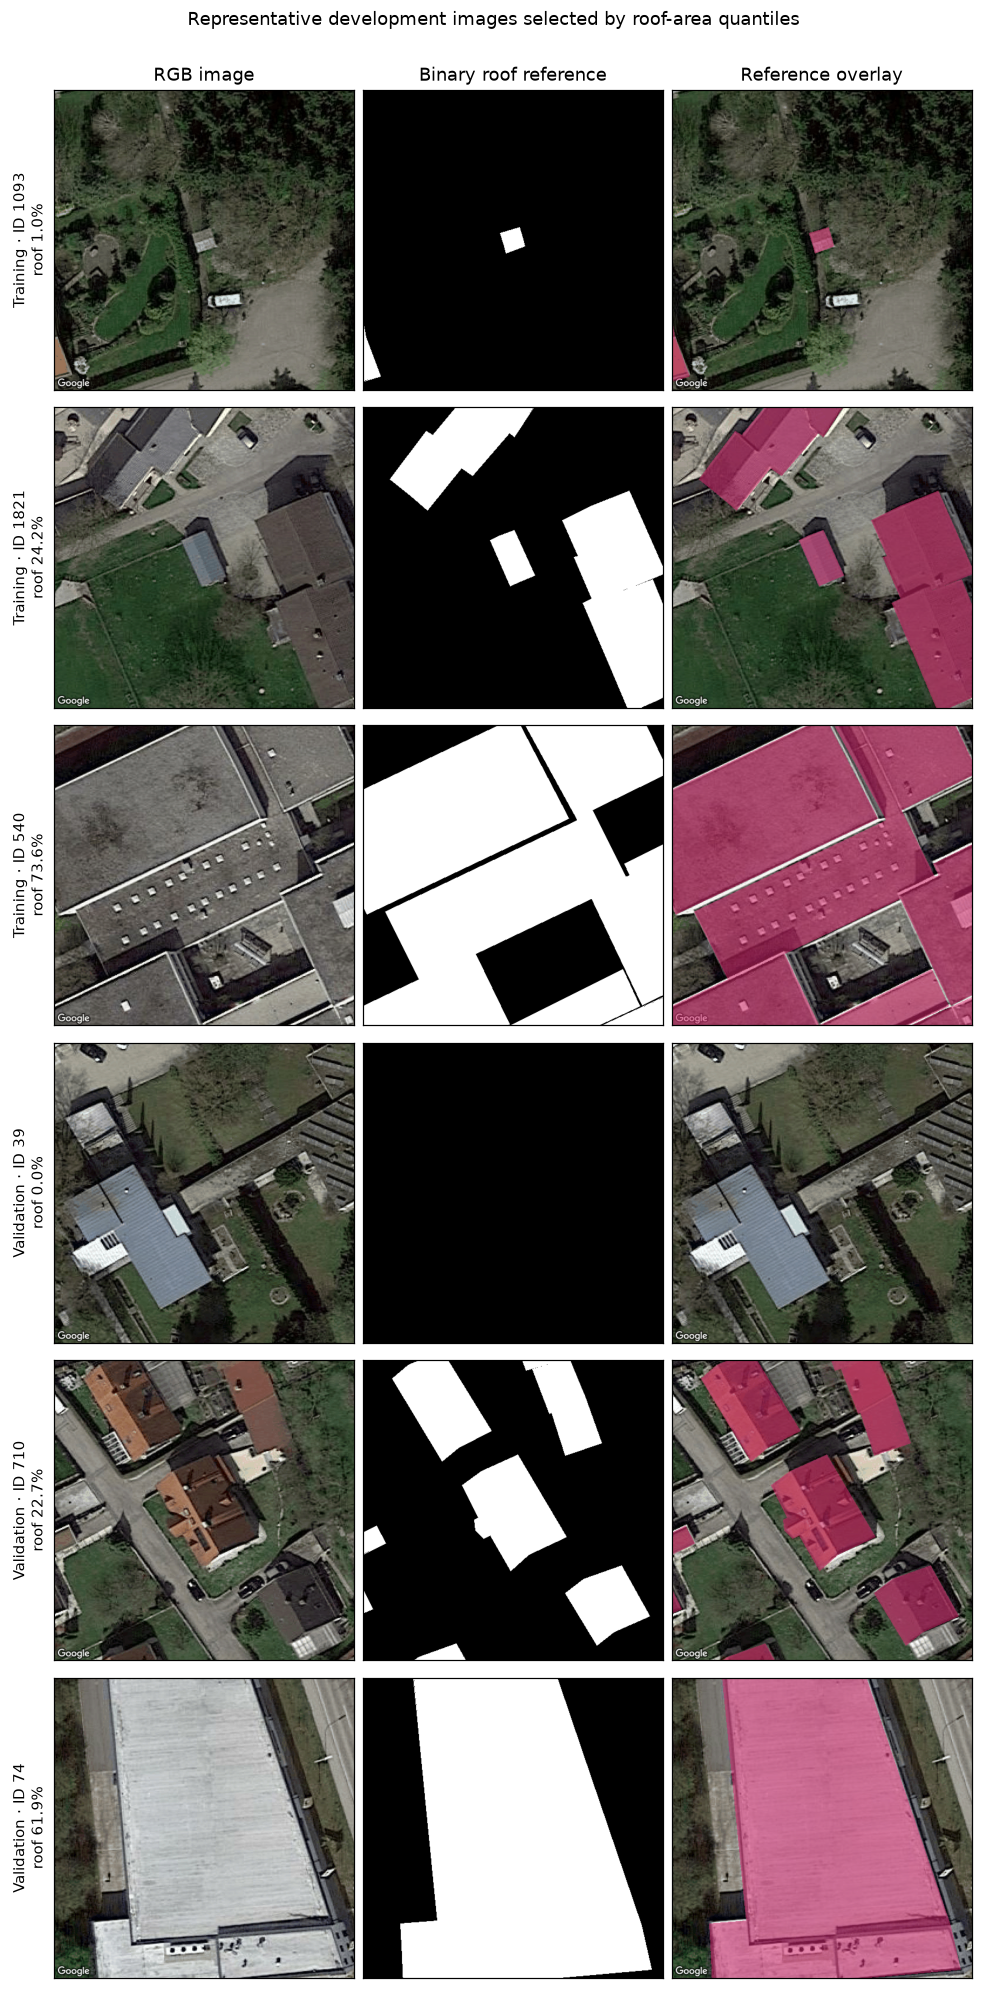

In [5]:
selections = representative_ids(MANIFEST, SPLITS, per_role=3)
figure = plot_examples(ROOT, MANIFEST, selections)
figure.savefig(ROOT / "reports/figures/development_examples.png", dpi=160, bbox_inches="tight")
plt.show()

**Observed examples.** The masks generally follow the central roof and sometimes include multiple roof planes or nearby connected roof parts. Background dominates low-area examples, while large roofs approach image borders. This motivates spatially consistent transformations later: images and masks must share geometry, image interpolation may be smooth, and categorical masks require nearest-neighbour interpolation. The gallery is a targeted visual audit, not an estimate of annotation error.

## 4. Duplicate and spatial leakage audit

An exact duplicate is a pair with identical provider-verified image bytes (and, here, identical mask bytes). This is stronger than visual similarity. We found 16 duplicate groups. Copies retained for development stay within a single provider role, but counting each copy as a separate labelled example would overstate the effective sample size; the final split keeps one representative per development group.

Geographic leakage is broader. Two different 512 × 512 images may show some of the same ground. We project each complete EPSG:4326 footprint to metric EPSG:25832 and call intersections larger than 0.01 m² an overlap. Provider D1 supplies the northern validation region and the same 154-image buffered test region used by all five supplied splits.

IDs,final role(s)
"47, 48, 49",excluded
"71, 72","excluded, validation"
"97, 98",excluded
"112, 113, 114","excluded, validation"
"134, 135","excluded, validation"
"289, 290, 291, 292",excluded
"318, 319","excluded, training"
"500, 501","excluded, training"
"647, 648","excluded, validation"
"672, 673","excluded, training"


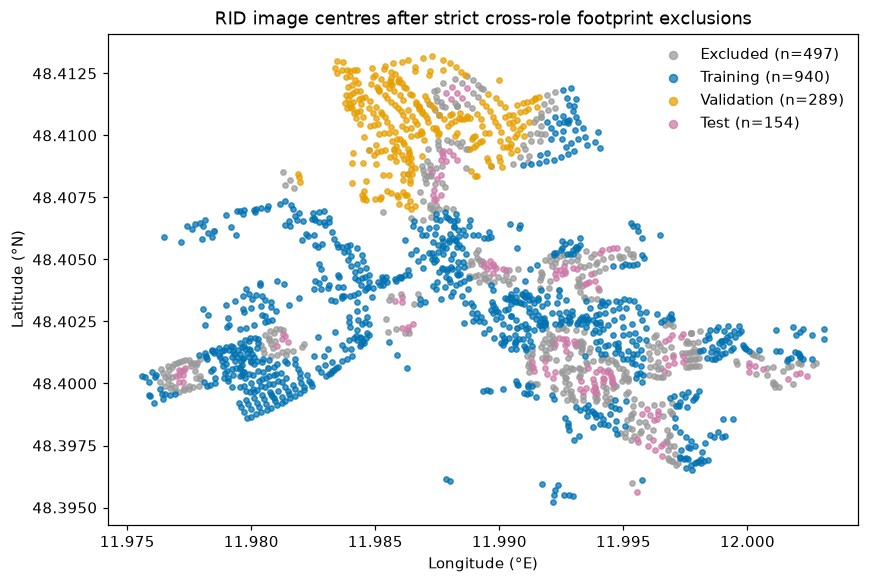

In [6]:
duplicate_rows = []
for group in MANIFEST["audit"]["exact_duplicate_image_groups"]:
    roles = sorted({role_by_id[sample_id] for sample_id in group})
    duplicate_rows.append({"IDs": ", ".join(group), "final role(s)": ", ".join(roles)})
display(pd.DataFrame(duplicate_rows).style.hide(axis="index"))

figure = plot_split_map(MANIFEST, SPLITS)
figure.savefig(ROOT / "reports/figures/geographic_split.png", dpi=160, bbox_inches="tight")
plt.show()

The map shows image centres for orientation; the exclusion decision itself uses full footprints. Grey samples are retained in the manifest but excluded from every experiment. The test region is fixed before training and is not used for subset selection.

In [7]:
before = SPLITS["spatial_audit"]["before"]
after = SPLITS["spatial_audit"]["after"]
summary = pd.DataFrame({
    "comparison": ["training–validation", "training–test", "validation–test"],
    "provider D1 overlap pairs": [before["training_validation_pair_count"], before["training_test_pair_count"], before["validation_test_pair_count"]],
    "final overlap pairs": [after["training_validation_pair_count"], after["training_test_pair_count"], after["validation_test_pair_count"]],
})
role_counts = pd.DataFrame({"role": SPLITS["counts"].keys(), "images": SPLITS["counts"].values()})
display(summary.style.hide(axis="index"), role_counts.style.hide(axis="index"))

comparison,provider D1 overlap pairs,final overlap pairs
training–validation,122,0
training–test,1329,0
validation–test,161,0


role,images
training,940
validation,289
test,154
excluded,497


**Verified finding.** Provider D1 contains 122 training–validation, 1,329 training–test and 161 validation–test footprint intersections. Removing the development-side crossings eliminates all positive-area cross-role intersections while preserving every provider test ID. Exact-duplicate filtering then leaves 940 training, 289 validation, 154 test and 497 excluded images.

**Limitation.** Disjoint footprints prevent the same visible pixels and buildings from crossing roles. They do not make nearby roofs, acquisition conditions or Google processing independent, and all data still come from one municipality. The 0.01 m² numerical tolerance ignores boundary-only contact and projection noise; it is not a geographic buffer. A stronger distance buffer would reduce the development pool further and remains a decision for discussion.

## 5. Training subsets for the later pilot

Within the retained training pool, each repetition starts from a seeded image and repeatedly adds the footprint centre farthest from the selected set (maximin sampling). This uses coordinates only—never masks, validation results or test appearance. Subsets of 25, 50, 100, 250 and 500 are nested within each repetition, followed by the complete training pool. Three repetitions provide paired but different spatial selections.

In [8]:
subset_rows = []
for repetition, config in SPLITS["training_subsets"]["repetitions"].items():
    subset_rows.append({
        "repetition": repetition,
        "seed": config["seed"],
        **{name: len(ids) for name, ids in config["subsets"].items()},
    })
display(pd.DataFrame(subset_rows).style.hide(axis="index"))

repetition,seed,25,50,100,250,500,full
1,17,25,50,100,250,500,940
2,29,25,50,100,250,500,940
3,43,25,50,100,250,500,940


These exact IDs make later pretrained-versus-random comparisons paired. Multiple overlapping views would still not be independent labels; exact duplicates have been removed, while other correlated views can remain inside the same training role. Validation annotations are additional to every stated training-label budget.

## 6. Conclusion and decisions before training

**Evidence supports using RID for a controlled pilot:** file pairing and checksums are complete, the binary mapping is now explicit, useful roof-area variation exists, and the final roles have no cross-role footprint overlap. The one empty validation mask should be retained and handled deliberately in metrics.

Before Stage 2, we should agree on two choices: (1) whether complete-footprint separation is sufficient or a nonzero geographic buffer is worth the loss of more data, and (2) whether the proposed 25/100/500 pilot sizes and three spatial repetitions give an appropriate first runtime/evidence trade-off. Only after that discussion should model training begin. The eventual evaluation must report uncertainty from the small, single-town setting and must not treat seed repetitions as independent geographic test regions.